In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
import nltk
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim
import re
from nltk.corpus import stopwords




data_folder = Path("./texts/Lovecraft/")

files = list(data_folder.glob("*.txt"))

files

[PosixPath('texts/Lovecraft/color_out_of_space.txt'),
 PosixPath('texts/Lovecraft/dunwich_horror.txt'),
 PosixPath('texts/Lovecraft/Call_of_cthulhu.txt'),
 PosixPath('texts/Lovecraft/shunned_house.txt')]

In [13]:
stories = {}

for file in files:
    with open(file, encoding="utf-8") as f:
        stories[file.stem] = f.read()

stories.keys()

dict_keys(['color_out_of_space', 'dunwich_horror', 'Call_of_cthulhu', 'shunned_house'])

In [14]:
print(stories["Call_of_cthulhu"][:1000])

_1. The Horror in Clay._

The most merciful thing in the world, I think, is the inability of the
human mind to correlate all its contents. We live on a placid island
of ignorance in the midst of black seas of infinity, and it was not
meant that we should voyage far. The sciences, each straining in its
own direction, have hitherto harmed us little; but some day the piecing
together of dissociated knowledge will open up such terrifying vistas
of reality, and of our frightful position therein, that we shall either
go mad from the revelation or flee from the deadly light into the peace
and safety of a new dark age.

Theosophists have guessed at the awesome grandeur of the cosmic cycle
wherein our world and human race form transient incidents. They have
hinted at strange survivals in terms which would freeze the blood if
not masked by a bland optimism. But it is not from them that there
came the single glimpse of forbidden eons which chills me when I think
of it and maddens me when I dream 

In [15]:
stats = []

for title, text in stories.items():
    
    words = text.split()
    
    stats.append({
        "story": title,
        "word_count": len(words),
        "character_count": len(text)
    })

df = pd.DataFrame(stats)

df

,story,word_count,character_count
0,color_out_of_space,12364,69158
1,dunwich_horror,17183,100253
2,Call_of_cthulhu,11835,70258
3,shunned_house,10717,62939


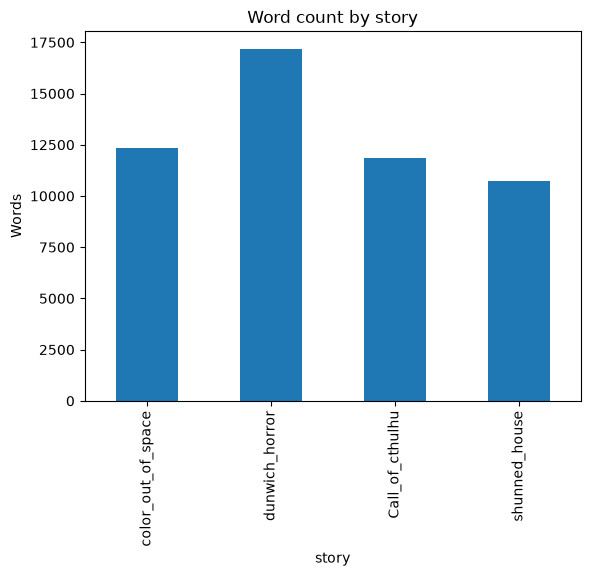

In [16]:
df.plot(
    x="story",
    y="word_count",
    kind="bar",
    legend=False
)

plt.title("Word count by story")
plt.ylabel("Words")
plt.show()

In [17]:
for title, text in stories.items():

    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

    print(
        title,
        "Words:", len(words),
        "Unique:", len(set(words))
    )

color_out_of_space Words: 12462 Unique: 2658
dunwich_horror Words: 17568 Unique: 3873
Call_of_cthulhu Words: 11881 Unique: 3068
shunned_house Words: 10829 Unique: 2913


In [21]:
cthulhu = stories["Call_of_cthulhu"]
words = re.findall(r"\b[a-zA-Z]+\b", cthulhu.lower())
Counter(words).most_common(20)

[('the', 804),
 ('of', 527),
 ('and', 483),
 ('a', 243),
 ('in', 219),
 ('to', 204),
 ('was', 170),
 ('had', 159),
 ('that', 119),
 ('i', 113),
 ('it', 110),
 ('he', 106),
 ('his', 96),
 ('which', 94),
 ('with', 86),
 ('from', 83),
 ('on', 79),
 ('for', 79),
 ('at', 74),
 ('as', 73)]